In [546]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [547]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [548]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [549]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [550]:
df.shape

(7043, 33)

In [551]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [552]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


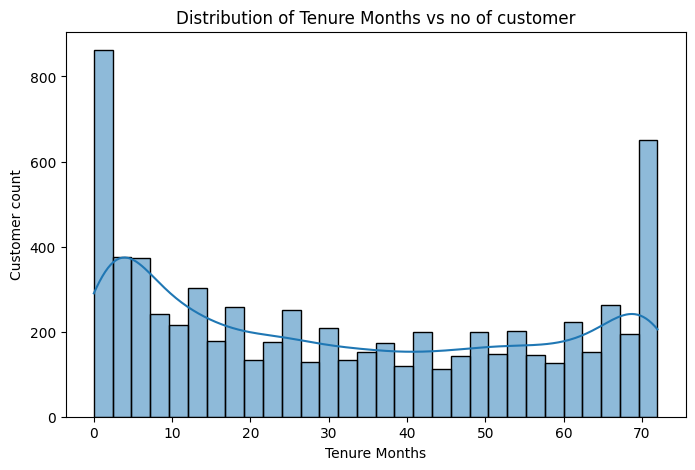

In [553]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'],bins=30, kde=True )
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

In [554]:
df['Tenure Months'].max()


72

In [555]:
df['Tenure Months'].min()

0

In [556]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

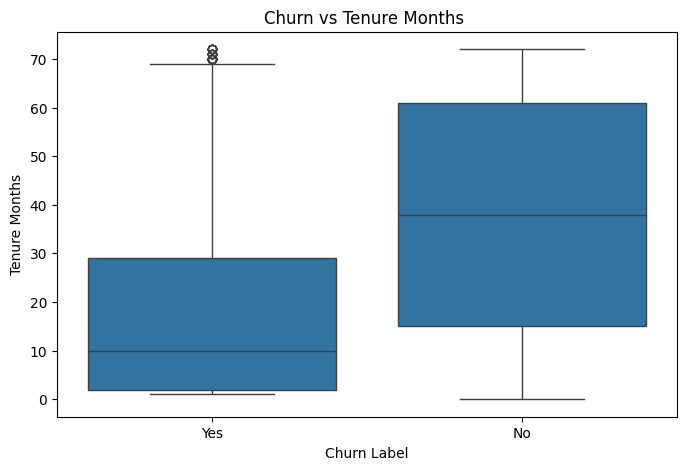

In [557]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label',y='Tenure Months',data=df )
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs Tenure Months ')
plt.show()

In [558]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [559]:
df[df['Churn Label']=='Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


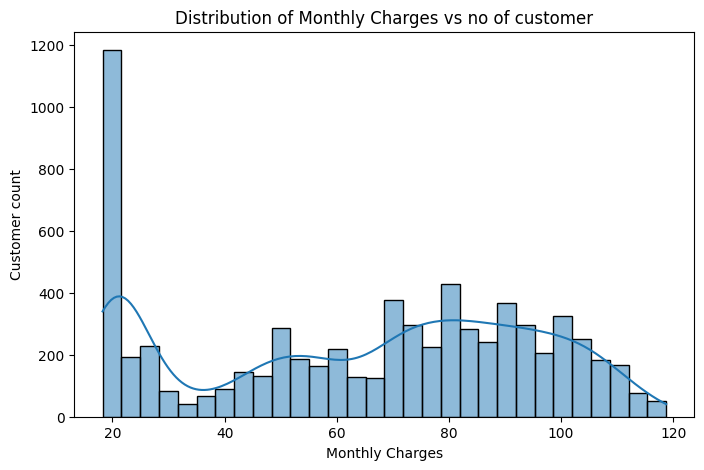

In [560]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'],bins=30, kde=True )
plt.xlabel('Monthly Charges')
plt.ylabel('Customer count')
plt.title('Distribution of Monthly Charges vs no of customer')
plt.show()

In [561]:
df['Monthly Charges'].min()

18.25

In [562]:
df['Monthly Charges'].max()

118.75

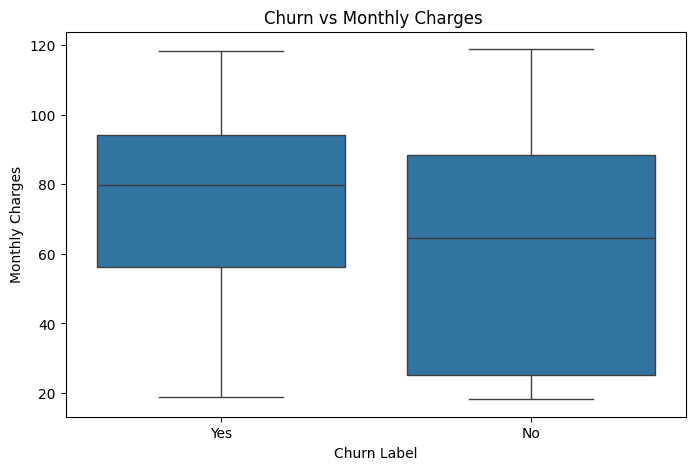

In [563]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label',y='Monthly Charges',data=df )
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Churn vs Monthly Charges ')
plt.show()

In [564]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [565]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [566]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [567]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

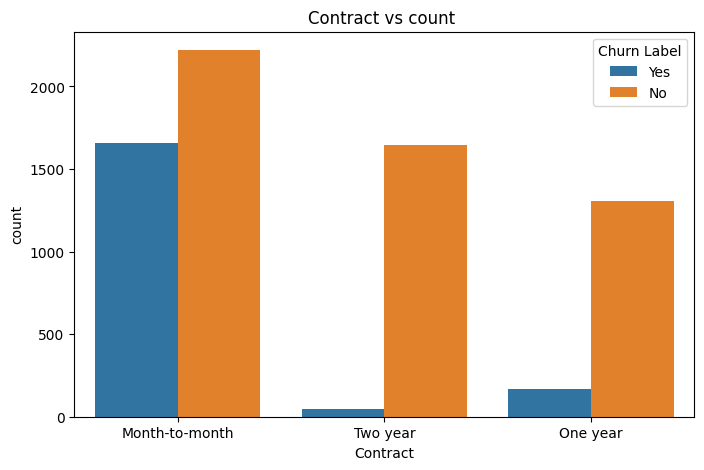

In [568]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract',hue='Churn Label',data=df )
plt.xlabel('Contract')
plt.ylabel('count')
plt.title('Contract vs count ')
plt.show()

In [569]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [570]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

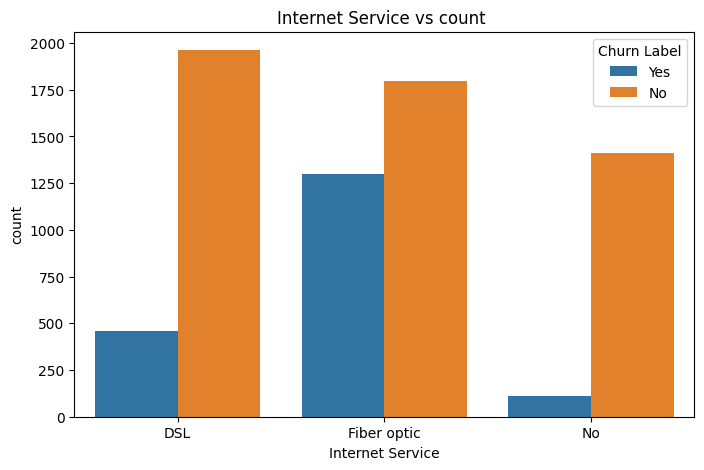

In [571]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service',hue='Churn Label',data=df )
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count ')
plt.show()

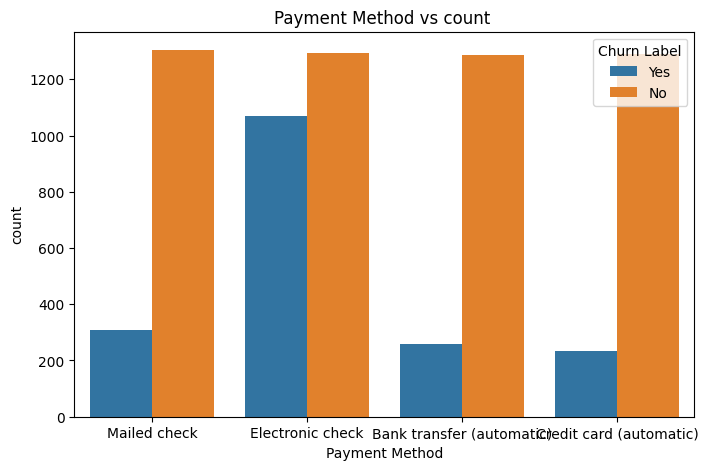

In [572]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method',hue='Churn Label',data=df )
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method vs count ')
plt.show()

In [573]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [574]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

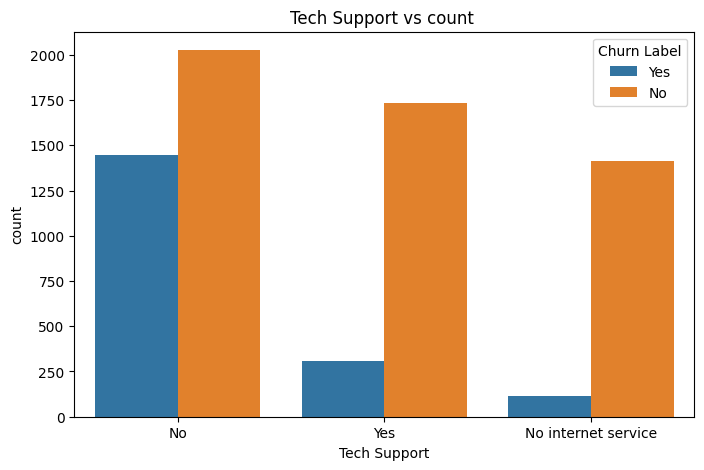

In [575]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support',hue='Churn Label',data=df )
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Tech Support vs count ')
plt.show()

In [576]:
avg_Tenure=df.groupby('Churn Label')['Tenure Months'].mean()

In [577]:
avg_Tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [578]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [579]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']
correlation_matrix=df[numerical_cols].corr()

In [580]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [581]:
Contract_Churn=pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
Contract_Churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Data Cleaning**

In [582]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [583]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [584]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [585]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [586]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [587]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [588]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [589]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [590]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']

In [591]:
df=df.drop(columns=drop_columns)

In [592]:
df.shape

(7043, 21)

In [593]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [594]:
df['City'].unique()
df['City'].value_counts()

,count
City,
Los Angeles,305
San Diego,150
San Jose,112
Sacramento,108
San Francisco,104
...,...
Chester,4
Big Bar,4
Washington,4


In [595]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [596]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [597]:
df_encoded.shape

(7043, 1159)

In [598]:
df=df.drop(columns=['City'])

In [599]:
df.shape

(7043, 20)

In [600]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [601]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [602]:
df_encoded.shape

(7043, 31)

In [603]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,True,False,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [604]:
X=df_encoded.drop('Churn Value',axis=1)
Y=df_encoded['Churn Value']

In [605]:
X.shape
Y.shape

(7043,)

In [606]:
print(X)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [607]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


**Machine Learing Implementation**

In [608]:
from sklearn.model_selection import train_test_split

In [609]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [610]:
X_train.shape

(5634, 30)

In [611]:
X_test.shape

(1409, 30)

In [612]:
Y_train.shape

(5634,)

In [613]:
Y_test.shape

(1409,)

lec 07 12th june

In [614]:
X_train, X_test, Y_train, Y_test

(      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
 2142             71            98.65        6962.85         True   
 1623             16            93.20        1573.70        False   
 6074             32           104.05        3416.85        False   
 1362             24            40.65         933.30        False   
 6754             20            20.05         406.05        False   
 ...             ...              ...            ...          ...   
 3772             42           100.40        4303.65        False   
 5191             39            20.70         762.45        False   
 5226             19            20.20         387.40         True   
 5390             35            19.90         666.00         True   
 860              31           103.45        3066.45         True   
 
       Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
 2142               False         True           False               True   
 1623           

In [615]:
from sklearn.ensemble import RandomForestClassifier


In [616]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [617]:
rf_model.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [618]:
y_pred=rf_model.predict(X_test)

In [619]:
Y_test

,Churn Value
185,1
2715,0
3825,0
1807,1
132,1
...,...
6366,0
315,1
2439,0
5002,0


In [620]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [621]:
from sklearn.metrics import accuracy_score

In [622]:
accuracy=accuracy_score(Y_test, y_pred)
print(accuracy)

0.7856635911994322


In [623]:
from sklearn.metrics import confusion_matrix

In [624]:
cm=confusion_matrix(Y_test, y_pred)

In [625]:
print(cm)

[[902 107]
 [195 205]]


In [626]:
from sklearn.metrics import classification_report

In [627]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach 1 - handle class imbalance**

In [628]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42, class_weight='balanced')
rf_balanced.fit(X_train,Y_train)
y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(Y_test, y_pred_balanced)
cm_balanced=confusion_matrix(Y_test, y_pred_balanced)
print(accuracy_balanced,cm_balanced)
print (classification_report(Y_test, y_pred_balanced))


0.7920511000709723 [[907 102]
 [191 209]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach 2 Hyperparameter tuning**

In [629]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_tuned.fit(X_train,Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

**Approach 3  Hyperparameter Tuning using GridSearchCV**

In [630]:
from sklearn.model_selection import GridSearchCV


In [631]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}


In [632]:
best_rf = grid_search.best_estimator_

In [633]:
y_pred_grid = best_rf.predict(X_test)

In [634]:
from sklearn.metrics import accuracy_score, recall_score, classification_report

print("Accuracy :", accuracy_score(Y_test, y_pred_grid))
print("Recall :", recall_score(Y_test, y_pred_grid))
print(classification_report(Y_test, y_pred_grid))

Accuracy : 0.7452093683463449
Recall : 0.82
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1009
           1       0.53      0.82      0.65       400

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [635]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest + GridSearchCV"],
    "Accuracy": [0.7828, 0.7452],
    "Recall": [0.7475, 0.8200]
})

comparison

,Model,Accuracy,Recall
0,Random Forest,0.7828,0.7475
1,Random Forest + GridSearchCV,0.7452,0.8200


In [636]:
import pandas as pd
feature_importance =pd.DataFrame({
    'features':X.columns,
    'importance':best_rf.feature_importances_
})
feature_importance=feature_importance.sort_values(by='importance',ascending=False)
print(feature_importance)



                                  features  importance
0                            Tenure Months    0.190380
25                       Contract_Two year    0.160933
2                            Total Charges    0.092504
10            Internet Service_Fiber optic    0.084438
6                           Dependents_Yes    0.077948
28         Payment Method_Electronic check    0.065107
1                          Monthly Charges    0.041241
24                       Contract_One year    0.038842
13                     Online Security_Yes    0.034576
12     Online Security_No internet service    0.025270
18        Tech Support_No internet service    0.025204
22    Streaming Movies_No internet service    0.024461
16   Device Protection_No internet service    0.022429
11                     Internet Service_No    0.020622
19                        Tech Support_Yes    0.019501
20        Streaming TV_No internet service    0.018081
14       Online Backup_No internet service    0.017059
26        

In [637]:
print(feature_importance.tail(15))

                                  features  importance
20        Streaming TV_No internet service    0.018081
14       Online Backup_No internet service    0.017059
26                   Paperless Billing_Yes    0.007437
15                       Online Backup_Yes    0.005992
5                              Partner_Yes    0.005749
9                       Multiple Lines_Yes    0.003496
27  Payment Method_Credit card (automatic)    0.003083
23                    Streaming Movies_Yes    0.003005
17                   Device Protection_Yes    0.002988
4                       Senior Citizen_Yes    0.002682
29             Payment Method_Mailed check    0.001923
21                        Streaming TV_Yes    0.001696
3                              Gender_Male    0.001138
7                        Phone Service_Yes    0.001112
8          Multiple Lines_No phone service    0.001103


In [638]:
X_selected=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [639]:
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected, Y, test_size=0.2, random_state=42
)

In [640]:
rf_selected=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(X_train_sel,Y_train_sel)
y_pred_selected=rf_selected.predict(X_test_sel)

print (classification_report(Y_test_sel, y_pred_selected)
)

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



approach estimation of trees and graph

In [641]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [642]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]
for n_trees in n_estimators_list:
  for depth in max_depth_list:
    rf=RandomForestClassifier(n_estimators=n_trees,max_depth=depth,random_state=42,class_weight='balanced')
    rf.fit(X_train,Y_train)
    y_pred=rf.predict(X_test)
    accuracy=accuracy_score(Y_test,y_pred)
    recall= recall_score(Y_test,y_pred)
    precision=precision_score(Y_test,y_pred)
    f1=f1_score(Y_test,y_pred)
    results.append ({'Trees': n_trees, 'Depth':depth, 'Accuracy':accuracy,'Recall':recall,'precision': precision,'F1 Score':f1})
result_df=pd.DataFrame(results)
result_df=result_df.sort_values(by=['Recall','Accuracy'],ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  precision  F1 Score
0     100      5  0.745919  0.8200   0.534202  0.646943
8     300      5  0.743790  0.8200   0.531605  0.645034
12    400      5  0.743790  0.8125   0.531915  0.642928
4     200      5  0.742370  0.8100   0.530278  0.640950
16    500      5  0.740951  0.8050   0.528736  0.638256
1     100     10  0.775727  0.7525   0.581081  0.655773
9     300     10  0.782825  0.7475   0.593254  0.661504
13    400     10  0.782825  0.7475   0.593254  0.661504
17    500     10  0.781405  0.7475   0.590909  0.660044
5     200     10  0.782115  0.7450   0.592445  0.660022
10    300     15  0.806246  0.6400   0.664935  0.652229
14    400     15  0.803407  0.6375   0.658915  0.648030
18    500     15  0.801987  0.6375   0.655527  0.646388
6     200     15  0.804826  0.6350   0.663185  0.648787
2     100     15  0.802697  0.6300   0.659686  0.644501
3     100     20  0.787793  0.5325   0.655385  0.587586
7     200     20  0.793471  0.5275   0.674121  0

In [643]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')


In [644]:
cv_accuracy=cross_val_score(best_rf,X,Y,cv=5,scoring='accuracy')


In [645]:
cv_accuracy

array([0.74662881, 0.77501774, 0.73527324, 0.74076705, 0.75213068])

In [646]:
cv_accuracy.mean()

np.float64(0.7499635057100458)

In [647]:
cv_recall=cross_val_score(best_rf,X,Y,cv=5,scoring='recall')

In [648]:
cv_recall

array([0.81550802, 0.8342246 , 0.8368984 , 0.79946524, 0.80160858])

In [649]:
cv_recall.mean()

np.float64(0.8175409671545928)

In [650]:
from sklearn.metrics import roc_auc_score,roc_curve

In [651]:
import matplotlib.pyplot as plt

In [652]:
y_prob1=best_rf.predict_proba(X_test)

In [653]:
y_prob=best_rf.predict_proba(X)

In [654]:
churn_probability=y_prob[:, 1]

In [655]:
churn_prob= y_prob1[:,1]

In [656]:
fpr,tpr,threshold=roc_curve(Y_test,churn_prob)
auc_score= roc_auc_score(Y_test,churn_prob)
print(auc_score)

0.8501362735381567


Customer Segmentation


In [657]:
segmentation_data=pd.DataFrame({
    'Tenure Months':X['Tenure Months'],
    'Monthly Charges':X['Monthly Charges'],
    'Total Charges':X['Total Charges'],
    'Churn Probability':churn_probability})

In [658]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.647584
1,2,70.70,151.65,0.735051
2,8,99.65,820.50,0.686652
3,28,104.80,3046.05,0.437300
4,49,103.70,5036.30,0.388417
...,...,...,...,...
7038,72,21.15,1419.40,0.046364
7039,24,84.80,1990.50,0.208178
7040,72,103.20,7362.90,0.259130
7041,11,29.60,346.45,0.513920


Implementation

In [659]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [660]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   0.87780468]
 [-1.23672422  0.19736523 -0.93887444  1.21625924]
 [-0.99240204  1.1595457  -0.64378925  1.02897666]
 [-0.17799476  1.33071079  0.3380854   0.0641069 ]
 [ 0.67713287  1.29415125  1.2161497  -0.1250492 ]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

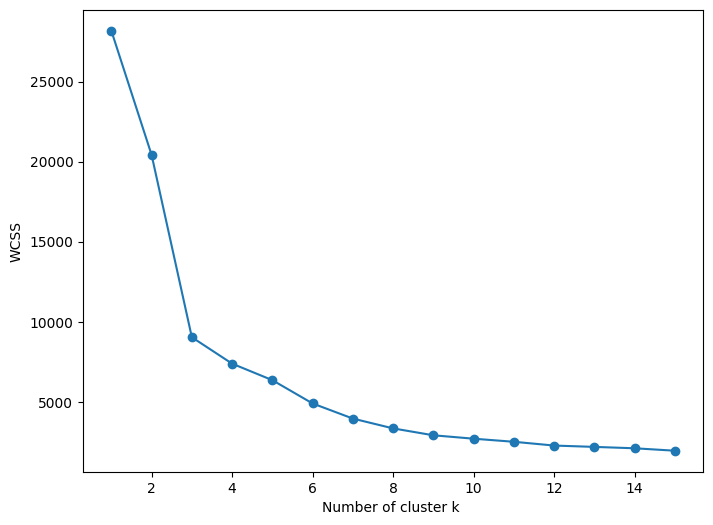

In [661]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of cluster k ")
plt.ylabel("WCSS")
plt.show()


In [662]:
kmeans=KMeans(n_clusters=3, random_state=42)

In [663]:
clusters=kmeans.fit_predict(scaled_data)

In [664]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.647584
1,2,70.70,151.65,0.735051
2,8,99.65,820.50,0.686652
3,28,104.80,3046.05,0.437300
4,49,103.70,5036.30,0.388417
...,...,...,...,...
7038,72,21.15,1419.40,0.046364
7039,24,84.80,1990.50,0.208178
7040,72,103.20,7362.90,0.259130
7041,11,29.60,346.45,0.513920


In [665]:
segmentation_data['Cluster']=clusters

In [666]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.647584,2
1,2,70.70,151.65,0.735051,2
2,8,99.65,820.50,0.686652,2
3,28,104.80,3046.05,0.437300,1
4,49,103.70,5036.30,0.388417,1
...,...,...,...,...,...
7038,72,21.15,1419.40,0.046364,0
7039,24,84.80,1990.50,0.208178,0
7040,72,103.20,7362.90,0.259130,1
7041,11,29.60,346.45,0.513920,2


In [667]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [668]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,34.105783,29.448047,1041.506154,0.179587
1,58.129460,90.299062,5248.357228,0.320470
2,11.264291,70.271507,873.780116,0.670209


In [669]:
cluster_names={
    0:'Budget Loyal customers',
    1:'High Risk New Customers',
    2:'Loyal Premium Customers',
}

In [670]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)

In [671]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.647584,2,Loyal Premium Customers
1,2,70.70,151.65,0.735051,2,Loyal Premium Customers
2,8,99.65,820.50,0.686652,2,Loyal Premium Customers
3,28,104.80,3046.05,0.437300,1,High Risk New Customers
4,49,103.70,5036.30,0.388417,1,High Risk New Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.046364,0,Budget Loyal customers
7039,24,84.80,1990.50,0.208178,0,Budget Loyal customers
7040,72,103.20,7362.90,0.259130,1,High Risk New Customers
7041,11,29.60,346.45,0.513920,2,Loyal Premium Customers


In [672]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

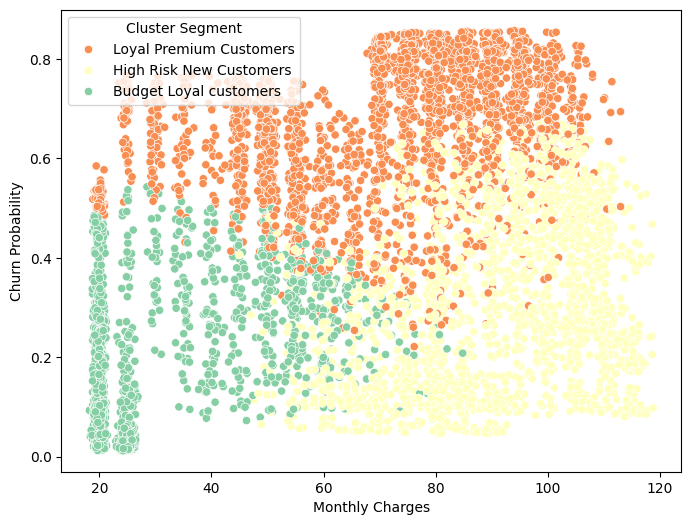

In [673]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Monthly Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

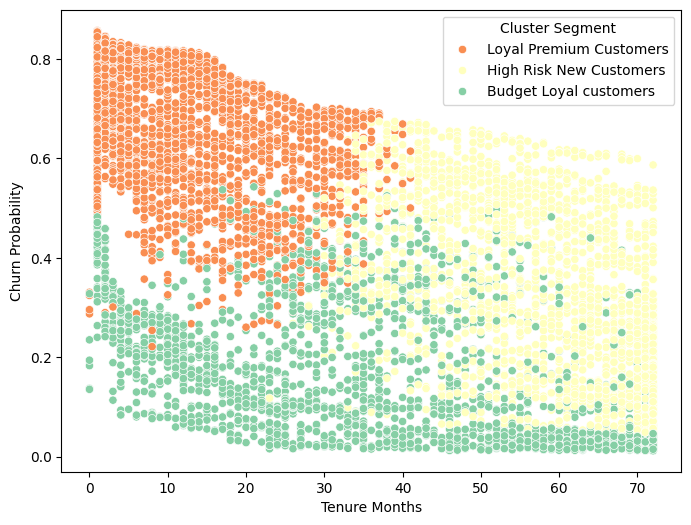

In [674]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Tenure Months', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: xlabel='Total Charges', ylabel='Churn Probability'>

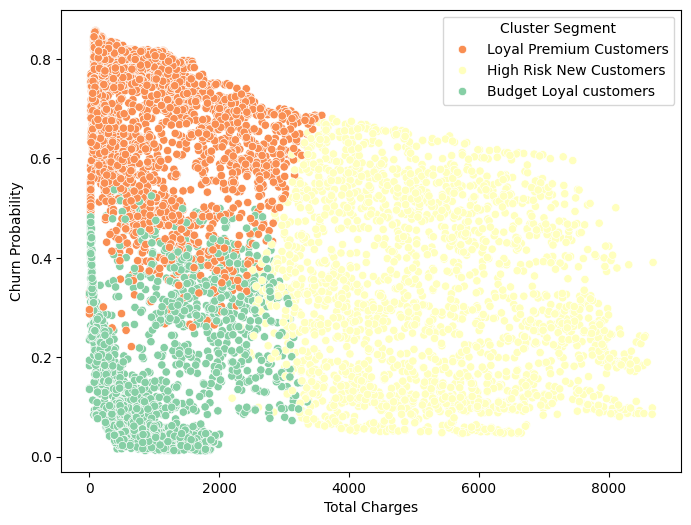

In [675]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

In [676]:
best_rf

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5, n_estimators=300, random_state=42)

## Final Conclusion

- Built a Customer Churn Prediction model using Random Forest.
- Improved the model using GridSearchCV.
- Final Model Performance:
  - Accuracy: **74.52%**
  - Recall: **82.00%**
- Used K-Means clustering for customer segmentation.